
**Dropout** is a technique used in training neural networks to help them learn better and avoid making mistakes when they see new data. Here’s a simple breakdown of the dropout theory:

### 🔍 What is Dropout?

- **Purpose**: The main goal of dropout is to prevent **overfitting**. Overfitting happens when a model learns too much from the training data, including noise and details that don’t help it perform well on new data.

### 🌟 How Does Dropout Work?

1. **Randomly Turning Off Neurons**: During training, dropout randomly "turns off" a certain percentage of neurons (like turning off lights in a room). For example, if we set a dropout rate of 50%, half of the neurons will be ignored in each training step.

2. **Learning with Less Information**: By turning off some neurons, the model learns to make decisions without relying too much on any single neuron. This helps it become more flexible and better at generalizing to new data.

3. **Scaling Outputs**: When neurons are turned off, the outputs of the remaining active neurons are scaled up. This means that the overall output remains balanced, so the model can still learn effectively.

### 📈 Benefits of Dropout

- **Better Generalization**: Models that use dropout tend to perform better on new, unseen data because they are not overly reliant on specific neurons.
- **Simplicity**: Dropout is easy to implement and can be added to existing models without much complexity.



## 🔮 How Dropout Works During Prediction

During the prediction phase, the dropout layer behaves differently compared to the training phase. Understanding this difference is crucial for grasping how dropout impacts the model's performance when making predictions.

### 🔄 Behavior During Prediction

- **All Neurons Active**: Unlike during training, where a random subset of neurons is deactivated, during prediction, **all neurons are active**. This means that the entire network is utilized to make predictions.
- **Scaling of Outputs**: To account for the neurons that were dropped during training, the outputs of the neurons are typically scaled down. This scaling is done by multiplying the outputs by the probability of keeping a neuron active (1 - dropout rate). For example, if the dropout rate is 0.5, the outputs are multiplied by 0.5 during inference.

### 📊 Example of Prediction with Dropout

Let’s consider a simple example to illustrate how dropout affects predictions:

1. **Training Phase**:
   - Suppose you have a dropout rate of 0.5.
   - During training, each neuron has a 50% chance of being dropped out. This means that the model learns to make predictions based on various combinations of neurons.

2. **Prediction Phase**:
   - When making predictions, all neurons are used.
   - The outputs from the neurons are scaled down by 0.5 to ensure that the expected output remains consistent with what the model learned during training.

### 🧩 Impact on Predictions

- **Improved Generalization**: By using dropout during training, the model learns to generalize better, which often leads to improved performance on unseen data during prediction.
- **Reduced Overfitting**: Since the model does not rely on specific neurons, it is less likely to overfit to the training data, resulting in more reliable predictions.

### 🧠 Conclusion

In summary, during the prediction phase, the dropout layer allows all neurons to contribute to the output while scaling their contributions to maintain consistency with the training phase. This mechanism helps ensure that the model generalizes well to new data, leading to more accurate predictions.

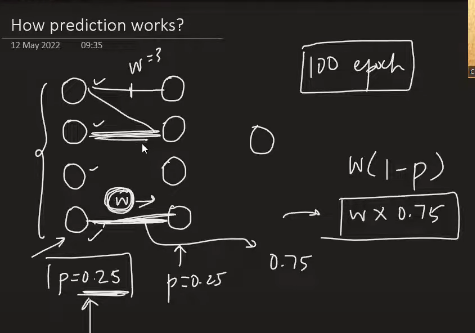

## 🌳 Analogy of Dropout with Random Forests and Ensemble Learning

To understand dropout in neural networks, we can use an analogy with **Random Forests** and **Ensemble Learning**. Both concepts involve combining multiple models to improve performance, and they share some similarities with how dropout works in neural networks.

### 🔄 The Analogy

1. **Random Forests**:
   - **Multiple Decision Trees**: A random forest is made up of many decision trees. Each tree is trained on a different subset of the data, and they make predictions independently.
   - **Diversity**: Just like dropout randomly turns off neurons, random forests randomly select features and data samples for each tree. This diversity helps the overall model make better predictions by reducing the risk of overfitting to any single tree's quirks.

2. **Ensemble Learning**:
   - **Combining Models**: Ensemble learning combines the predictions of multiple models to create a stronger overall model. For example, it might average the predictions of several different algorithms.
   - **Robustness**: Similar to dropout, which prevents any single neuron from dominating the learning process, ensemble methods ensure that no single model has too much influence. This leads to more robust and reliable predictions.

### 🌟 Key Similarities

- **Reducing Overfitting**: Both dropout and ensemble methods like random forests aim to reduce overfitting. Dropout does this by randomly deactivating neurons, while random forests do it by averaging the predictions of multiple trees.
- **Encouraging Diversity**: Dropout encourages the network to learn diverse features by forcing it to rely on different combinations of neurons. In the same way, random forests create diversity by using different subsets of data and features for each tree.

### 🧠 Conclusion

In summary, dropout in neural networks can be thought of as a way to create a diverse ensemble of neurons, similar to how random forests use multiple decision trees. Both techniques aim to improve model performance and reduce overfitting by ensuring that no single component dominates the learning process. This analogy helps illustrate the importance of diversity and robustness in machine learning models.

## 📐 Comprehensive Mathematical Breakdown of Dropout

To fully understand how dropout works mathematically, we will explore the various components involved, including the forward pass, backward pass, and the implications for weight updates.

### 🔍 1. Forward Pass with Dropout

During the forward pass, dropout randomly deactivates a fraction of neurons. Here’s how it works mathematically:

- **Input Layer**: Let \( \mathbf{x} \) be the input vector to a layer.
- **Weights**: Let \( \mathbf{W} \) be the weight matrix for that layer.
- **Bias**: Let \( \mathbf{b} \) be the bias vector.
- **Output Before Activation**: The output before applying the activation function is given by:
  \[
  \mathbf{h} = \mathbf{W} \cdot \mathbf{x} + \mathbf{b}
  \]

- **Dropout Mask**: A binary mask \( \mathbf{m} \) is created, where each element is 1 (keep) or 0 (drop) based on the dropout rate \( p \). The mask is generated as follows:
  \[
  m_i \sim \text{Bernoulli}(1 - p)
  \]
  where \( m_i \) is the mask for the \( i \)-th neuron.

- **Output After Dropout**: The output after applying dropout is:
  \[
  \mathbf{h}_{dropout} = \mathbf{h} \odot \mathbf{m}
  \]

- **Scaling**: To maintain the expected output, the output is scaled:
  \[
  \mathbf{h}_{scaled} = \frac{\mathbf{h}_{dropout}}{1 - p}
  \]

### 🔄 2. Backward Pass with Dropout

During the backward pass, the gradients are computed only for the active neurons:

- **Loss Function**: Let \( L \) be the loss function. The gradient of the loss with respect to the output is:
  \[
  \frac{\partial L}{\partial \mathbf{h}}
  \]

- **Gradient with Dropout**: The gradient is then modified by the dropout mask:
  \[
  \frac{\partial L}{\partial \mathbf{h}_{dropout}} = \frac{\partial L}{\partial \mathbf{h}} \odot \mathbf{m}
  \]

- **Weight Update**: The weight update rule can be expressed as:
  \[
  \Delta \mathbf{W} = -\eta \cdot \frac{\partial L}{\partial \mathbf{W}} \quad \text{(where \( \eta \) is the learning rate)}
  \]

### 📈 3. Weight Initialization and Effective Weights

- **Weight Initialization**: Weights are typically initialized using methods like Xavier or He initialization, which consider the number of input and output neurons. This ensures that the weights are set to values that help in effective learning.

- **Effective Weight Update**: With dropout, the effective weight update can be thought of as:
  \[
  \Delta \mathbf{W}_{effective} = \Delta \mathbf{W} \cdot (1 - p)
  \]
  This means that the weight updates are scaled down based on the dropout rate.

### 🔄 4. Prediction Phase

During the prediction phase, all neurons are active, and the dropout layer is effectively turned off:

- **Output During Prediction**: The output is simply:
  \[
  \mathbf{h}_{pred} = \mathbf{W} \cdot \mathbf{x} + \mathbf{b}
  \]

- **No Scaling**: There is no need for scaling during prediction since all neurons contribute to the output.

### 🧠 Conclusion

The mathematical workings of dropout involve a series of steps during both the forward and backward passes. By randomly deactivating neurons and scaling the outputs, dropout helps prevent overfitting while maintaining the expected output. The effective weight updates during training ensure that the model learns robust features, leading to better generalization during the prediction phase. This comprehensive understanding of the mathematics behind dropout highlights its importance in training deep learning models.

#effects of p

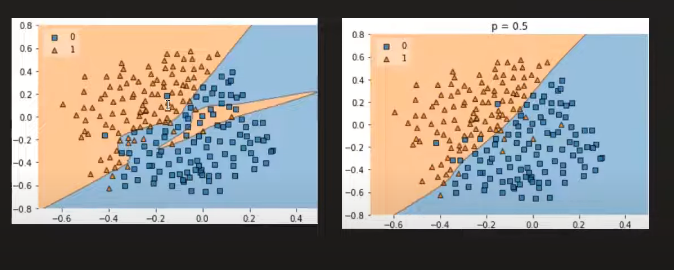

##Effects of p



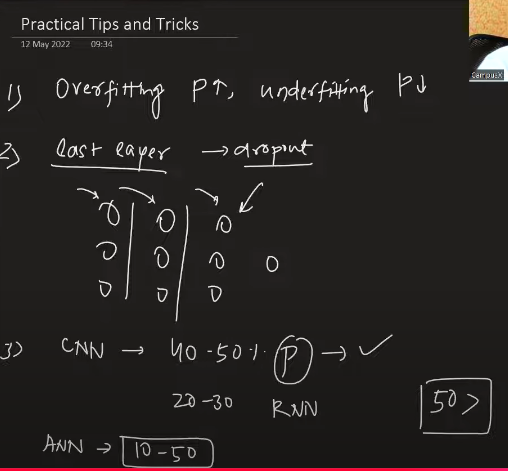

#Drawbacks

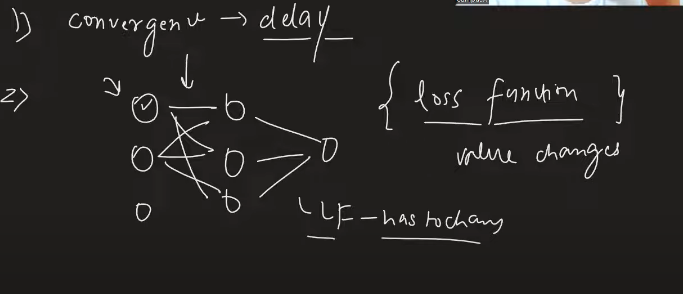

In [2]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
import numpy as np # Assuming numpy might be used for data

# Define input_dim (replace with the actual number of features in your data)
input_dim = 10 # Placeholder value

# Create dummy data for demonstration (replace with your actual data)
X_train = np.random.rand(100, input_dim)
y_train = np.random.randint(0, 2, 100)
X_val = np.random.rand(20, input_dim)
y_val = np.random.randint(0, 2, 20)


# Create a simple neural network model
model = Sequential()
model.add(Dense(128, activation='relu', input_shape=(input_dim,)))  # Input layer
model.add(Dropout(0.5))  # Dropout layer with 50% dropout rate
model.add(Dense(64, activation='relu'))  # Hidden layer
model.add(Dropout(0.5))  # Another dropout layer
model.add(Dense(1, activation='sigmoid'))  # Output layer for binary classification

# Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Fit the model on training data
model.fit(X_train, y_train, epochs=10, batch_size=32, validation_data=(X_val, y_val))

Epoch 1/10


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 81ms/step - accuracy: 0.4434 - loss: 0.7150 - val_accuracy: 0.3000 - val_loss: 0.7455
Epoch 2/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.4863 - loss: 0.7070 - val_accuracy: 0.3000 - val_loss: 0.7324
Epoch 3/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.5311 - loss: 0.6835 - val_accuracy: 0.2500 - val_loss: 0.7340
Epoch 4/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.4948 - loss: 0.6970 - val_accuracy: 0.2500 - val_loss: 0.7372
Epoch 5/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.4963 - loss: 0.7033 - val_accuracy: 0.3500 - val_loss: 0.7414
Epoch 6/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.4128 - loss: 0.7174 - val_accuracy: 0.3000 - val_loss: 0.7384
Epoch 7/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.5030 - loss: 0.7057 - val_accuracy: 0.2500 - val_loss: 0.7342
Epoch 8/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.5459 - loss: 0.6766 - val_accuracy: 0.3000 - val_loss: 0.7283
Epoch 9/10
